# Cell 1: Tải dữ liệu và mã hóa nhãn

In [1]:
import pandas as pd
import numpy as np
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import sys

sys.path.append('../')
from src.models.semi_supervised import SemiSupervisedTrainer

df = pd.read_csv('../data/processed/cleaned_reviews.csv')
tfidf_matrix = sparse.load_npz('../data/processed/tfidf_matrix.npz')

def get_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['reviews.rating'].apply(get_sentiment)

le = LabelEncoder()
y_encoded = le.fit_transform(df['sentiment'])

X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
    tfidf_matrix, y_encoded, df.index, test_size=0.2, random_state=42, stratify=y_encoded
)

/var/folders/s3/h6hv6qkd01d4qr6_nb2f3m3m0000gn/T/ipykernel_10522/4161417405.py:12: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/processed/cleaned_reviews.csv')


# Cell 2: Giả lập thiếu nhãn và huấn luyện (Learning Curve)

In [2]:
ratios = [0.05, 0.10, 0.20, 0.30]
f1_supervised_list = []
f1_semi_list = []
best_semi_model = None

trainer = SemiSupervisedTrainer()

for ratio in ratios:
    f1_sup, f1_semi, model = trainer.evaluate_scenario(
        X_train, y_train, X_test, y_test, ratio
    )
    f1_supervised_list.append(f1_sup)
    f1_semi_list.append(f1_semi)
    if ratio == 0.10:
        best_semi_model = model

print(f1_supervised_list)
print(f1_semi_list)

[0.3781202463878162, 0.45367343891525586, 0.5073553482648362, 0.5289313193765867]
[0.27234186358511914, 0.39498664568148856, 0.49134630143509544, 0.5069314316107221]


# Cell 3: Vẽ biểu đồ Learning Curve (Ăn điểm Rubric F)

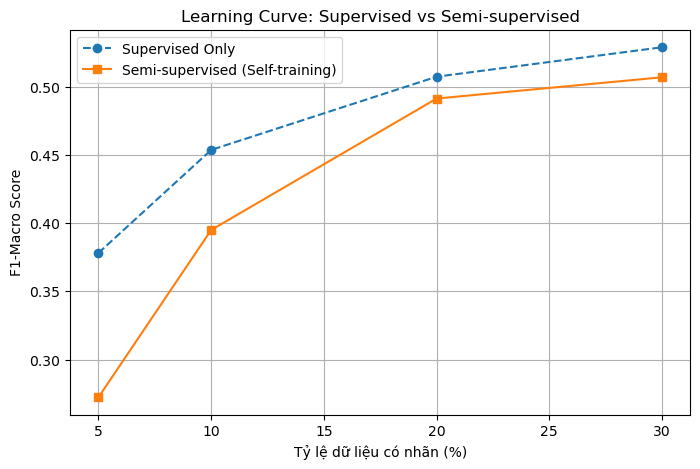

In [3]:
plt.figure(figsize=(8, 5))
plt.plot(np.array(ratios) * 100, f1_supervised_list, marker='o', label='Supervised Only', linestyle='--')
plt.plot(np.array(ratios) * 100, f1_semi_list, marker='s', label='Semi-supervised (Self-training)')
plt.title('Learning Curve: Supervised vs Semi-supervised')
plt.xlabel('Tỷ lệ dữ liệu có nhãn (%)')
plt.ylabel('F1-Macro Score')
plt.legend()
plt.grid(True)
plt.show()

# Cell 4: Phân tích Pseudo-label sai ở review ngắn

In [4]:
df_test = df.loc[indices_test].copy()
y_pred_best = best_semi_model.predict(X_test)
df_test['predicted_encoded'] = y_pred_best
df_test['predicted_sentiment'] = le.inverse_transform(y_pred_best)

errors = df_test[df_test['sentiment'] != df_test['predicted_sentiment']]

short_errors = errors[errors['reviews.text'].str.len() < 50]

display(short_errors[['reviews.rating', 'sentiment', 'predicted_sentiment', 'reviews.text']].head(10))

,reviews.rating,sentiment,predicted_sentiment,reviews.text
24366,5.0,Positive,Neutral,Super sjour. Rien a redire
19588,3.0,Neutral,Positive,nice room. comfy bed.
29452,1.0,Negative,Positive,I am convinced I got bit by bedbugs here!
33231,3.0,Neutral,Positive,Great room for the price.
7875,3.0,Neutral,Positive,great rooms and meeting spaces
13976,3.0,Neutral,Positive,Average rooms and prices
20232,2.0,Negative,Positive,Postage stamp fitness room
20300,1.0,Negative,Positive,Not good
28994,4.0,Positive,Neutral,Hotel trs correct pour le prix
26874,2.5,Negative,Positive,Nothing
